<a href="https://colab.research.google.com/github/DhimanTarafdar/AAA/blob/main/improve_the_model_performance_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Block 1.1: Load data**

In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 49.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from Bio import SeqIO

sequences = {r.id: str(r.seq) for r in SeqIO.parse("titered_E_aa.mfa", "fasta")}
labels = pd.read_csv("elife-42496-fig1-data1-v3.csv")
labels = labels.rename(columns={"titer": "antigenic_distance"})
print(labels.shape)
labels.head()

(540, 3)


,serum,antigenic_distance,virus
0,DENV1/BOLIVIA/FSB3363/2010,0.000000,DENV1/BOLIVIA/FSB3363/2010
1,DENV1/CAMBODIA/BIDV1991/2003,1.494765,DENV1/BOLIVIA/FSB3363/2010
2,DENV1/MYANMAR/61117/2005,1.782562,DENV1/BOLIVIA/FSB3363/2010
3,DENV1/NAURU/WESTERNPACIFICDELTA30/1974,0.058894,DENV1/BOLIVIA/FSB3363/2010
4,DENV1/PERU/IQT6152/2000,2.459432,DENV1/BOLIVIA/FSB3363/2010


# **Block 1.2: Serotype of each strain**

In [ ]:
def get_serotype(name):
    return name.split("/")[0]

labels["serum_sero"] = labels["serum"].map(get_serotype)
labels["virus_sero"] = labels["virus"].map(get_serotype)
labels["same_sero"] = labels["serum_sero"] == labels["virus_sero"]

print(pd.Series({k: get_serotype(k) for k in sequences}).value_counts())
print(labels.groupby(["serum_sero", "virus_sero"]).size().unstack(fill_value=0))

DENV2    16
DENV4    13
DENV1    10
DENV3     9
Name: count, dtype: int64
virus_sero  DENV1  DENV2  DENV3  DENV4
serum_sero                            
DENV1          58     38     17     13
DENV2          29    113     28     18
DENV3          20     35     65     11
DENV4           9     25     11     50


# **Block 1.3: Pair structure (leakage check)**

In [ ]:
print("Unique sera:", labels["serum"].nunique())
print("Unique viruses:", labels["virus"].nunique())
print("Self pairs (serum = virus):", (labels["serum"] == labels["virus"]).sum())

pair_set = set(zip(labels["serum"], labels["virus"]))
n_reverse = sum((v, s) in pair_set for s, v in pair_set if s != v)
print("Pairs whose reverse also exists:", n_reverse)

print(labels.groupby("serum").size().describe())

Unique sera: 32
Unique viruses: 46
Self pairs (serum = virus): 30
Pairs whose reverse also exists: 188
count    32.00000
mean     16.87500
std       8.35406
min       3.00000
25%      11.00000
50%      15.00000
75%      20.25000
max      39.00000
dtype: float64


# **Block 1.4: Target distribution**

In [ ]:
print(labels["antigenic_distance"].describe())
print(labels.groupby("same_sero")["antigenic_distance"].describe())
print(labels[labels["same_sero"]].groupby("serum_sero")["antigenic_distance"].describe())

count    540.000000
mean       1.242120
std        1.916463
min       -3.788918
25%        0.000000
50%        0.784271
75%        2.055504
max        7.729961
Name: antigenic_distance, dtype: float64
           count      mean       std       min       25%       50%       75%  \
same_sero                                                                      
False      254.0  2.107565  2.050577 -1.963474  0.579129  1.291374  3.447459   
True       286.0  0.473508  1.397518 -3.788918 -0.239372  0.220458  1.234221   

                max  
same_sero            
False      7.729961  
True       5.221104  
            count      mean       std       min       25%       50%       75%  \
serum_sero                                                                      
DENV1        58.0  0.490130  1.515451 -3.788918 -0.304897  0.029447  1.637158   
DENV2       113.0  0.697928  1.607628 -3.147252 -0.071553  0.494765  1.288968   
DENV3        65.0  0.671858  1.021310 -1.325044  0.000000  0.61364

# **Block 1.5: Distance histogram (same vs cross serotype)**

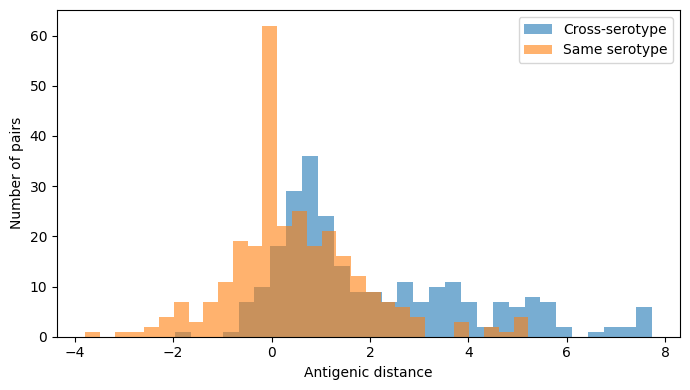

In [ ]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(labels.loc[~labels["same_sero"], "antigenic_distance"], bins=30, alpha=0.6, label="Cross-serotype")
ax.hist(labels.loc[labels["same_sero"], "antigenic_distance"], bins=30, alpha=0.6, label="Same serotype")
ax.set_xlabel("Antigenic distance")
ax.set_ylabel("Number of pairs")
ax.legend()
plt.tight_layout()
plt.show()

# **Block 1.6: Which serum-virus pairs were measured**

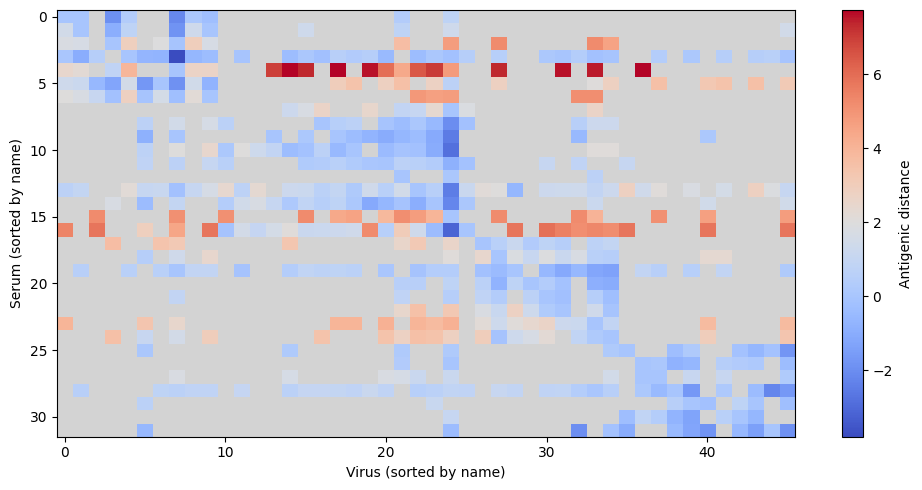

In [ ]:
matrix = labels.pivot(index="serum", columns="virus", values="antigenic_distance")
matrix = matrix.sort_index().sort_index(axis=1)

cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(np.ma.masked_invalid(matrix.values), cmap=cmap, aspect="auto")
plt.colorbar(im, label="Antigenic distance")
ax.set_xlabel("Virus (sorted by name)")
ax.set_ylabel("Serum (sorted by name)")
plt.tight_layout()
plt.show()

# **Stage 2: Strict validation and honest baseline**

# **Block 2.1: Remove self pairs**

In [ ]:
data = labels[labels["serum"] != labels["virus"]].reset_index(drop=True)
print("After removing self pairs:", data.shape)

After removing self pairs: (510, 6)


# **Block 2.2: How much variance is serum/virus specific?**

In [ ]:
def eta_squared_adj(df, col):
    y = df["antigenic_distance"]
    total = ((y - y.mean()) ** 2).sum()
    within = df.groupby(col)["antigenic_distance"].apply(lambda s: ((s - s.mean()) ** 2).sum()).sum()
    n, k = len(df), df[col].nunique()
    return 1 - (within / (n - k)) / (total / (n - 1))

for name, df in [("all pairs", data), ("same serotype", data[data["same_sero"]])]:
    print(name, "| serum:", round(eta_squared_adj(df, "serum"), 3), "| virus:", round(eta_squared_adj(df, "virus"), 3))

all pairs | serum: 0.573 | virus: -0.009
same serotype | serum: 0.537 | virus: 0.258


# **Block 2.3: Old features (same as your notebook)**

In [ ]:
from Bio import SeqIO
from scipy.stats import spearmanr

charge = {"R": 1, "H": 1, "K": 1, "D": -1, "E": -1}
hydro = dict(A=1.8, R=-4.5, N=-3.5, D=-3.5, C=2.5, Q=-3.5, E=-3.5, G=-0.4, H=-3.2, I=4.5,
             L=3.8, K=-3.9, M=1.9, F=2.8, P=-1.6, S=-0.8, T=-0.7, W=-0.9, Y=-1.3, V=4.2)
volume = dict(A=88.6, R=173.4, N=114.1, D=111.1, C=108.5, Q=143.8, E=138.4, G=60.1, H=153.2, I=166.7,
              L=166.7, K=168.6, M=162.9, F=189.9, P=112.7, S=89.0, T=116.1, W=227.8, Y=193.6, V=140.0)

def compute_features(seq1, seq2):
    n_sub = d_charge = d_hydro = d_size = n_skipped = 0
    for a, b in zip(seq1, seq2):
        if a == b:
            continue
        if a not in hydro or b not in hydro:
            n_skipped += 1
            continue
        n_sub += 1
        d_charge += abs(charge.get(a, 0) - charge.get(b, 0))
        d_hydro += abs(hydro[a] - hydro[b])
        d_size += abs(volume[a] - volume[b])
    return n_sub, d_charge, d_hydro, d_size, n_skipped

feature_cols = ["num_substitutions", "total_abs_charge_change",
                "total_abs_hydrophobicity_change", "total_abs_size_change"]
rows = [compute_features(sequences[s], sequences[v]) for s, v in zip(data["serum"], data["virus"])]
features = pd.DataFrame(rows, columns=feature_cols + ["skipped_positions"])
data = pd.concat([data, features], axis=1)
data["same_sero_int"] = data["same_sero"].astype(int)
print(data[feature_cols].describe().round(2))

       num_substitutions  total_abs_charge_change  \
count             510.00                   510.00   
mean               83.93                    24.18   
std                73.92                    22.67   
min                 0.00                     0.00   
25%                12.00                     2.00   
50%                34.00                     8.50   
75%               155.00                    45.00   
max               186.00                    63.00   

       total_abs_hydrophobicity_change  total_abs_size_change  
count                           510.00                 510.00  
mean                            172.06                2626.65  
std                             158.25                2341.59  
min                               0.00                   0.00  
25%                              16.63                 366.80  
50%                              72.95                1062.75  
75%                             333.28                5124.93  
max       

# **Block 2.4: Why the old features are weak (plot)**

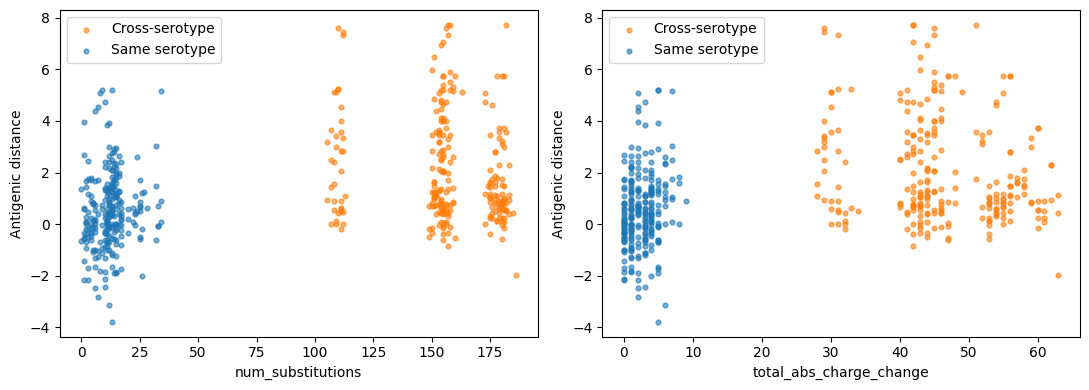

same_sero = False | Spearman(substitutions, distance) = -0.137
same_sero = True | Spearman(substitutions, distance) = 0.179


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["num_substitutions", "total_abs_charge_change"]):
    for flag, color, label in [(False, "tab:orange", "Cross-serotype"), (True, "tab:blue", "Same serotype")]:
        part = data[data["same_sero"] == flag]
        ax.scatter(part[col], part["antigenic_distance"], s=12, alpha=0.6, color=color, label=label)
    ax.set_xlabel(col)
    ax.set_ylabel("Antigenic distance")
    ax.legend()
plt.tight_layout()
plt.show()

for flag in [False, True]:
    part = data[data["same_sero"] == flag]
    rho = spearmanr(part["num_substitutions"], part["antigenic_distance"])[0]
    print("same_sero =", flag, "| Spearman(substitutions, distance) =", round(rho, 3))

# **Block 2.5: Strict strain-level splits**

In [ ]:
# A test strain is removed from training in both roles (serum and virus)
# new_virus: test pairs have a new virus
# both_new: test pairs have a new virus AND a new serum
def strain_splits(data, mode, n_splits=4, n_repeats=10, seed=0):
    strains = np.array(sorted(set(data["serum"]) | set(data["virus"])))
    rng = np.random.default_rng(seed)
    splits = []
    for rep in range(n_repeats):
        fold_of = dict(zip(strains, rng.permutation(len(strains)) % n_splits))
        s_fold = data["serum"].map(fold_of).values
        v_fold = data["virus"].map(fold_of).values
        for k in range(n_splits):
            train = (s_fold != k) & (v_fold != k)
            if mode == "new_virus":
                test = (v_fold == k)
            else:
                test = (v_fold == k) & (s_fold == k)
            splits.append((rep, np.where(train)[0], np.where(test)[0]))
    return splits

schemes = {"new_virus": strain_splits(data, "new_virus"),
           "both_new": strain_splits(data, "both_new")}

for name, sp in schemes.items():
    print(name, "| avg train pairs:", int(np.mean([len(t) for _, t, _ in sp])),
          "| avg test pairs:", int(np.mean([len(e) for _, _, e in sp])))

new_virus | avg train pairs: 285 | avg test pairs: 127
both_new | avg train pairs: 285 | avg test pairs: 30


# **Block 2.6: CV and scoring functions**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def run_cv(make_model, data, cols, splits):
    X = data[cols].values
    y = data["antigenic_distance"].values
    out = []
    for rep, tr, te in splits:
        if len(te) < 5:
            continue
        model = make_model()
        model.fit(X[tr], y[tr])
        out.append(pd.DataFrame({"rep": rep, "idx": te, "pred": model.predict(X[te])}))
    return pd.concat(out, ignore_index=True)

subsets = {
    "all": np.ones(len(data), dtype=bool),
    "same_serotype": data["same_sero"].values,
    "DENV2_vs_DENV2": ((data["serum_sero"] == "DENV2") & (data["virus_sero"] == "DENV2")).values,
}

def score(oof, data, subsets):
    y = data["antigenic_distance"].values
    out = []
    for rep, g in oof.groupby("rep"):
        idx, pred = g["idx"].values, g["pred"].values
        for name, mask in subsets.items():
            keep = mask[idx]
            if keep.sum() < 8:
                continue
            yt, yp = y[idx][keep], pred[keep]
            out.append({"rep": rep, "subset": name,
                        "rmse": np.sqrt(mean_squared_error(yt, yp)),
                        "mae": mean_absolute_error(yt, yp),
                        "r2": r2_score(yt, yp),
                        "spearman": spearmanr(yt, yp)[0]})
    return pd.DataFrame(out)

# **Block 2.7: Honest scores of baselines and your old RF**

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

models = {
    "Dummy (mean)": (lambda: DummyRegressor(strategy="mean"), feature_cols),
    "Serotype-group mean": (lambda: LinearRegression(), ["same_sero_int"]),
    "Substitutions only": (lambda: LinearRegression(), ["num_substitutions"]),
    "RF (old setup)": (lambda: RandomForestRegressor(max_depth=3, min_samples_leaf=20,
                        n_estimators=300, random_state=42, n_jobs=-1), feature_cols),
}

all_scores, all_oof = [], {}
for scheme, splits in schemes.items():
    for model_name, (make_model, cols) in models.items():
        oof = run_cv(make_model, data, cols, splits)
        sc = score(oof, data, subsets)
        sc["scheme"], sc["model"] = scheme, model_name
        all_scores.append(sc)
        all_oof[(scheme, model_name)] = oof

all_scores = pd.concat(all_scores)
summary = all_scores.groupby(["scheme", "subset", "model"])[["rmse", "mae", "r2", "spearman"]].mean().round(3)
print(summary)

                                               rmse    mae     r2  spearman
scheme    subset         model                                             
both_new  DENV2_vs_DENV2 Dummy (mean)         1.960  1.595 -0.171    -0.072
                         RF (old setup)       1.845  1.289 -0.029     0.202
                         Serotype-group mean  1.860  1.335 -0.043    -0.093
                         Substitutions only   1.851  1.350 -0.032     0.007
          all            Dummy (mean)         1.953  1.513 -0.048    -0.152
                         RF (old setup)       1.874  1.469  0.029     0.303
                         Serotype-group mean  1.828  1.466  0.079     0.226
                         Substitutions only   1.852  1.484  0.055     0.232
          same_serotype  Dummy (mean)         1.725  1.401 -0.336    -0.151
                         RF (old setup)       1.531  1.141 -0.043     0.063
                         Serotype-group mean  1.534  1.164 -0.048    -0.223
            

# **Block 2.8: Model vs baselines (plot)**

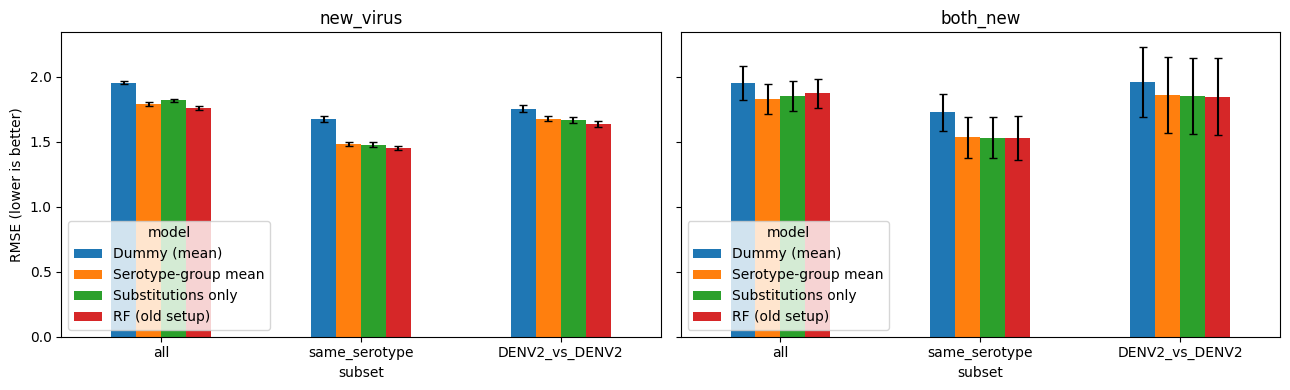

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, scheme in zip(axes, schemes):
    part = all_scores[all_scores["scheme"] == scheme]
    mean = part.groupby(["subset", "model"])["rmse"].mean().unstack()[list(models)].loc[list(subsets)]
    std = part.groupby(["subset", "model"])["rmse"].std().unstack()[list(models)].loc[list(subsets)]
    mean.plot(kind="bar", yerr=std, ax=ax, capsize=3, rot=0)
    ax.set_title(scheme)
    ax.set_ylabel("RMSE (lower is better)")
plt.tight_layout()
plt.show()

# **Block 2.9: Predicted vs actual (old RF, new_virus)**

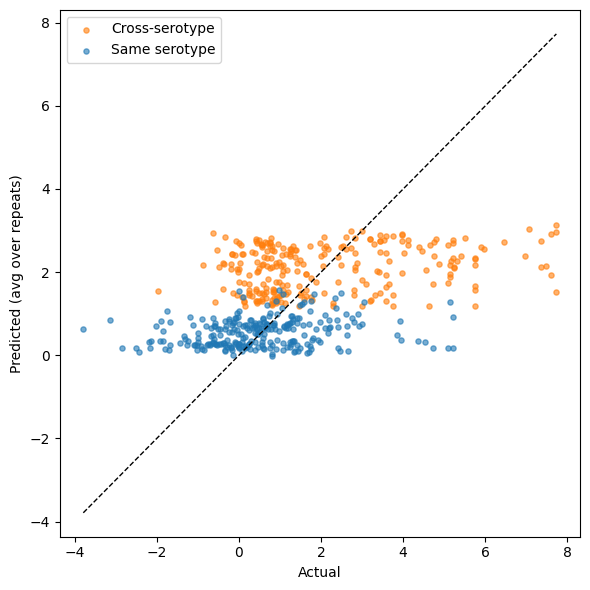

In [ ]:
oof = all_oof[("new_virus", "RF (old setup)")]
avg_pred = oof.groupby("idx")["pred"].mean()
plot_df = data.loc[avg_pred.index]

fig, ax = plt.subplots(figsize=(6, 6))
for flag, color, label in [(False, "tab:orange", "Cross-serotype"), (True, "tab:blue", "Same serotype")]:
    part = plot_df["same_sero"] == flag
    ax.scatter(plot_df.loc[part, "antigenic_distance"], avg_pred[part], s=14, alpha=0.6, color=color, label=label)
lims = [plot_df["antigenic_distance"].min(), plot_df["antigenic_distance"].max()]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted (avg over repeats)")
ax.legend()
plt.tight_layout()
plt.show()

# **Block 3.1: Serum offset (plot)**

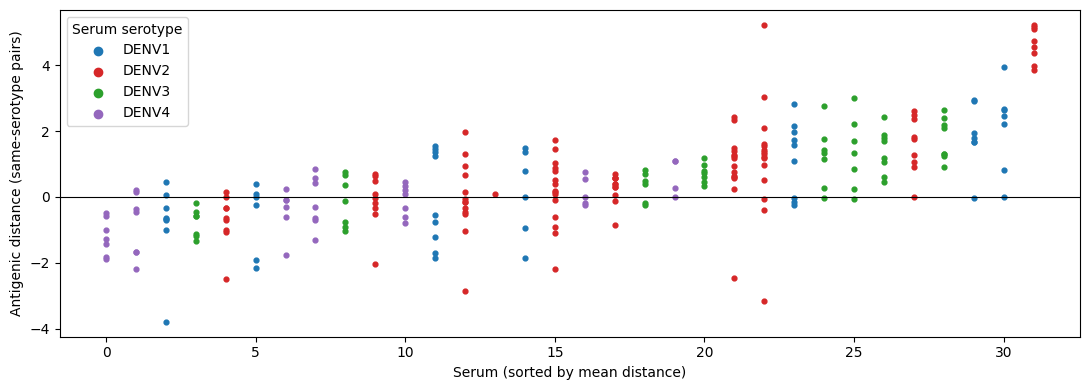

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

same = data[data["same_sero"]]
order = same.groupby("serum")["antigenic_distance"].mean().sort_values().index
colors = {"DENV1": "tab:blue", "DENV2": "tab:red", "DENV3": "tab:green", "DENV4": "tab:purple"}

fig, ax = plt.subplots(figsize=(11, 4))
for i, serum in enumerate(order):
    part = same[same["serum"] == serum]
    ax.scatter([i] * len(part), part["antigenic_distance"], s=12, color=colors[part["serum_sero"].iloc[0]])
for name, c in colors.items():
    ax.scatter([], [], color=c, label=name)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Serum (sorted by mean distance)")
ax.set_ylabel("Antigenic distance (same-serotype pairs)")
ax.legend(title="Serum serotype")
plt.tight_layout()
plt.show()

# **Block 3.2: Alignment check and variable positions (plot)**

Sequence lengths: {495} | sequences with gaps: 9
Positions differing in at least one same-serotype pair: 127 of 495


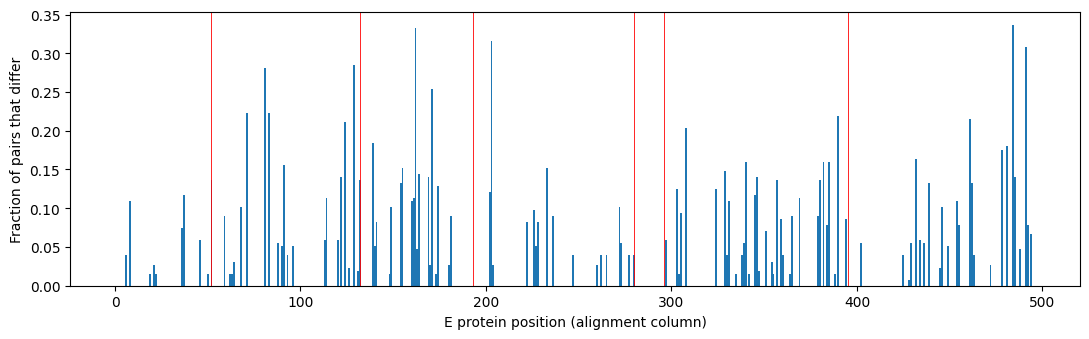

In [ ]:
lengths = set(len(s) for s in sequences.values())
n_gap = sum("-" in s for s in sequences.values())
print("Sequence lengths:", lengths, "| sequences with gaps:", n_gap)

seq_arr = {name: np.array(list(seq)) for name, seq in sequences.items()}
diff_same = np.array([seq_arr[s] != seq_arr[v] for s, v in zip(same["serum"], same["virus"])])
diff_freq = diff_same.mean(axis=0)
print("Positions differing in at least one same-serotype pair:", int((diff_freq > 0).sum()), "of", len(diff_freq))

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(np.arange(1, len(diff_freq) + 1), diff_freq, width=1.0)
for x in [52, 132, 193, 280, 296, 395]:   # approx domain borders, will verify
    ax.axvline(x, color="red", linewidth=0.6)
ax.set_xlabel("E protein position (alignment column)")
ax.set_ylabel("Fraction of pairs that differ")
plt.tight_layout()
plt.show()

# **Block 3.3: CV with options + within-serum score**

In [ ]:
def run_cv2(make_model, data, cols, splits, train_same_only=False, center_by_serum=False, min_serum_pairs=3):
    X = data[cols].values
    y = data["antigenic_distance"].values
    same_flag = data["same_sero"].values
    out = []
    for rep, tr, te in splits:
        if len(te) < 5:
            continue
        if train_same_only:
            tr = tr[same_flag[tr]]
        y_tr = y[tr].copy()
        if center_by_serum:
            # serum mean is taken from training pairs only
            train_df = data.iloc[tr]
            serum_mean = train_df.groupby("serum")["antigenic_distance"].transform("mean").values
            serum_n = train_df.groupby("serum")["antigenic_distance"].transform("size").values
            keep = serum_n >= min_serum_pairs
            y_tr = (y[tr] - serum_mean)[keep]
            tr = tr[keep]
        model = make_model()
        model.fit(X[tr], y_tr)
        pred = model.predict(X[te])
        if center_by_serum:
            pred = pred + y[tr].mean()
        out.append(pd.DataFrame({"rep": rep, "idx": te, "pred": pred}))
    return pd.concat(out, ignore_index=True)


def score_within(oof, data, mask, min_pairs=4):
    y = data["antigenic_distance"].values
    serum = data["serum"].values
    out = []
    for rep, g in oof.groupby("rep"):
        g = g[mask[g["idx"].values]]
        idx, pred = g["idx"].values, g["pred"].values
        res_sq, tot_sq, n_used, rhos = 0.0, 0.0, 0, []
        for s in np.unique(serum[idx]):
            pick = serum[idx] == s
            if pick.sum() < min_pairs:
                continue
            yt, yp = y[idx][pick], pred[pick]
            yt_c, yp_c = yt - yt.mean(), yp - yp.mean()
            res_sq += ((yt_c - yp_c) ** 2).sum()
            tot_sq += (yt_c ** 2).sum()
            n_used += pick.sum()
            if np.std(yp) > 0:
                rhos.append(spearmanr(yt, yp)[0])
        if n_used == 0:
            continue
        out.append({"rep": rep, "within_r2": 1 - res_sq / tot_sq,
                    "within_rmse": np.sqrt(res_sq / n_used),
                    "within_spearman": np.mean(rhos) if rhos else np.nan})
    return pd.DataFrame(out)

# **Block 3.4: Compare setups (old features, same splits)**

In [ ]:
rf = lambda: RandomForestRegressor(max_depth=3, min_samples_leaf=20, n_estimators=300,
                                   random_state=42, n_jobs=-1)
# (model, columns, train on same-serotype only, center by serum)
configs = {
    "Dummy (mean)": (lambda: DummyRegressor(), feature_cols, False, False),
    "RF all pairs (old)": (rf, feature_cols, False, False),
    "RF same-serotype": (rf, feature_cols, True, False),
    "RF same-serotype, serum-centered": (rf, feature_cols, True, True),
    "Ridge same-serotype, serum-centered": (lambda: make_pipeline(StandardScaler(), Ridge(alpha=10)), feature_cols, True, True),
    "Substitutions only, serum-centered": (lambda: LinearRegression(), ["num_substitutions"], True, True),
}

abs_scores, within_scores, oof_store = [], [], {}
for scheme, splits in schemes.items():
    for model_name, (make_model, cols, same_only, centered) in configs.items():
        oof = run_cv2(make_model, data, cols, splits, same_only, centered)
        oof_store[(scheme, model_name)] = oof
        sc = score(oof, data, subsets)
        sc["scheme"], sc["model"] = scheme, model_name
        abs_scores.append(sc)
        if scheme == "new_virus":
            for subset_name in ["same_serotype", "DENV2_vs_DENV2"]:
                ws = score_within(oof, data, subsets[subset_name])
                ws["subset"], ws["model"] = subset_name, model_name
                within_scores.append(ws)

abs_scores = pd.concat(abs_scores)
within_scores = pd.concat(within_scores)

pd.set_option("display.width", 200)
print(abs_scores[abs_scores["subset"] != "all"].groupby(["scheme", "subset", "model"])[["rmse", "r2", "spearman"]].mean().round(3))
print(within_scores.groupby(["subset", "model"])[["within_r2", "within_rmse", "within_spearman"]].mean().round(3))

                                                               rmse     r2  spearman
scheme    subset         model                                                      
both_new  DENV2_vs_DENV2 Dummy (mean)                         1.960 -0.171    -0.072
                         RF all pairs (old)                   1.845 -0.029     0.202
                         RF same-serotype                     1.852 -0.033     0.187
                         RF same-serotype, serum-centered     1.846 -0.029     0.140
                         Ridge same-serotype, serum-centered  1.841 -0.022     0.145
                         Substitutions only, serum-centered   1.851 -0.033     0.065
          same_serotype  Dummy (mean)                         1.725 -0.336    -0.151
                         RF all pairs (old)                   1.531 -0.043     0.063
                         RF same-serotype                     1.532 -0.045     0.070
                         RF same-serotype, serum-centered     1.5

# **Block 3.5: Results plot**

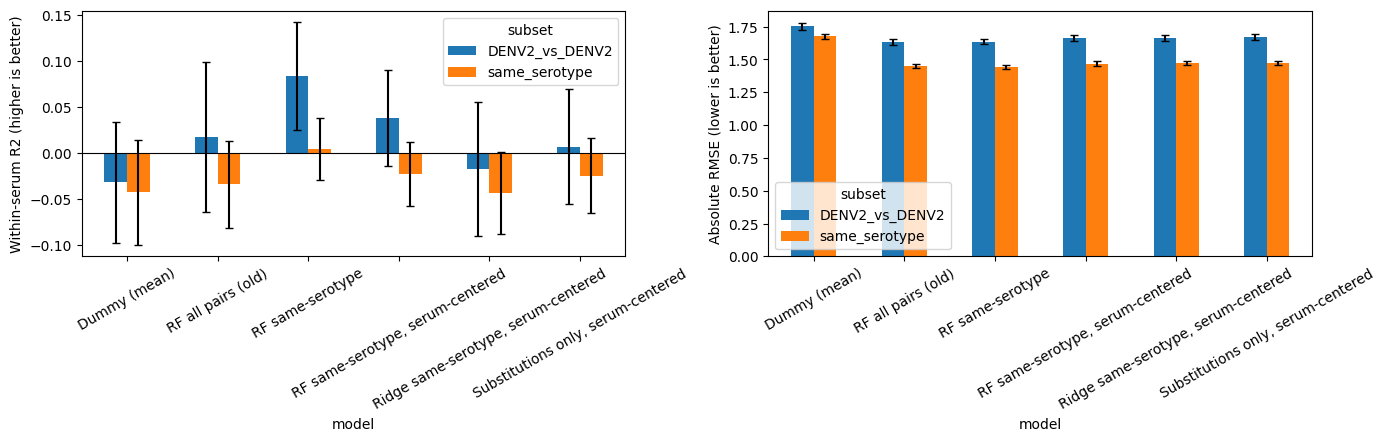

In [ ]:
order_models = list(configs)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

w = within_scores.groupby(["subset", "model"])["within_r2"].agg(["mean", "std"])
w["mean"].unstack()[order_models].T.plot(kind="bar", yerr=w["std"].unstack()[order_models].T,
                                          ax=axes[0], capsize=3, rot=30)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Within-serum R2 (higher is better)")

a = abs_scores[(abs_scores["scheme"] == "new_virus") &
               (abs_scores["subset"].isin(["same_serotype", "DENV2_vs_DENV2"]))]
m = a.groupby(["subset", "model"])["rmse"].mean().unstack()[order_models]
s = a.groupby(["subset", "model"])["rmse"].std().unstack()[order_models]
m.T.plot(kind="bar", yerr=s.T, ax=axes[1], capsize=3, rot=30)
axes[1].set_ylabel("Absolute RMSE (lower is better)")
plt.tight_layout()
plt.show()

# **Block 3.6: Within-serum predicted vs actual**

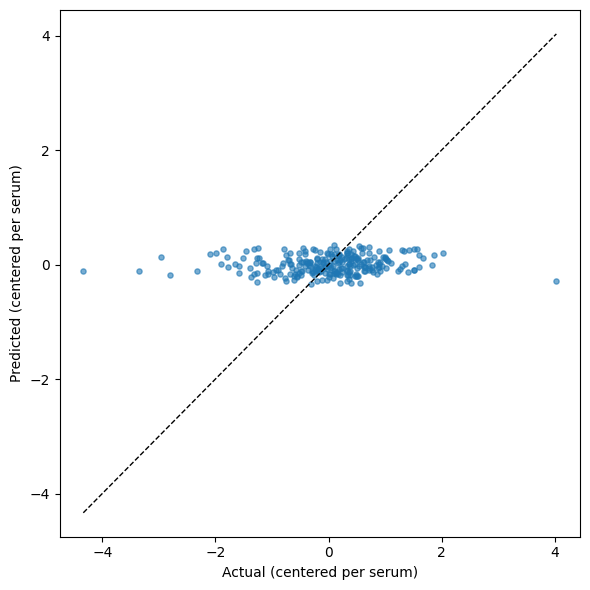

In [ ]:
best = "RF same-serotype, serum-centered"
oof = oof_store[("new_virus", best)]
avg = oof.groupby("idx")["pred"].mean()
df = data.loc[avg.index].copy()
df["pred"] = avg.values
df = df[subsets["same_serotype"][df.index]]
df["y_c"] = df["antigenic_distance"] - df.groupby("serum")["antigenic_distance"].transform("mean")
df["p_c"] = df["pred"] - df.groupby("serum")["pred"].transform("mean")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["y_c"], df["p_c"], s=14, alpha=0.6)
lims = [df["y_c"].min(), df["y_c"].max()]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("Actual (centered per serum)")
ax.set_ylabel("Predicted (centered per serum)")
plt.tight_layout()
plt.show()

# **A. Colab e Zenodo file gulo niye format dekha (Block 4.1)**

In [ ]:
import os
import urllib.request
import pandas as pd
from Bio import SeqIO

base = "https://zenodo.org/records/5365818/files/"
files = ["neutralization-titers.txt", "information.viruses.csv", "3d-antigenic-map.txt", "E-sequences.fasta"]
for f in files:
    if not os.path.exists(f):
        urllib.request.urlretrieve(base + f + "?download=1", f)
    print(f, os.path.getsize(f), "bytes")

for name in ["neutralization-titers.txt", "3d-antigenic-map.txt"]:
    print("-----", name)
    with open(name) as fh:
        for _ in range(8):
            print(fh.readline()[:300].rstrip())

info = pd.read_csv("information.viruses.csv")
print("-----", "information.viruses.csv", info.shape)
print(info.columns.tolist())
print(info.head(5).to_string()[:1500])

ids = [r.id for r in SeqIO.parse("E-sequences.fasta", "fasta")]
print("-----", "E-sequences.fasta:", len(ids), "sequences")
print(ids[:5])

neutralization-titers.txt 55740 bytes
information.viruses.csv 233405 bytes
3d-antigenic-map.txt 40243 bytes
E-sequences.fasta 3126292 bytes
----- neutralization-titers.txt
DEN1_BURMA_2005_61117 DEN1_CAMBODIA_2003_GENBANKGQ868619 DEN1_PERU_2000_IQT_6152 DEN1_PUERTORICO_2006_BID_V852 DEN1_VIETNAM_2008_BID_V1937 DEN2_CAMBODIA_2009_D2T0601085_KH09_KSP DEN2_MALAYSIA_2008_DKD811 DEN2_NICARAGUA_2006_BID_V571 DEN2_TONGA_1974_NIHVACCINE DEN2_VIETNAM_2006_BID_V735 DEN3_BURMA_20
DENV1/BOLIVIA/2010/FSB-3363 129 32 545 118 103 10 <10 <10 <10 16 19 17 <10 16 15 23 20 <10 <10 <10 * * * * * * * * * * * * * * * *
DENV1/CAMBODIA/2003/FJ639680 * * * 383 362 * <22 <22 <22 24 * * <22 * <22 * * <22 * <22 24 22 <22 <22 <22 <22 * * * * * * * * * *
DENV1/CAMBODIA/2003/GQ868619 259 68 1006 111 231 <22 <22 <22 <22 <22 <22 <22 <22 <22 <22 <22 <22 <22 <22 <22 <22 <22 <22 <22 <22 <22 37 <22 <22 <22 <22 <22 <22 <22 <22 <22
DENV1/CAMBODIA/2006/FJ639687 615 143 1258 197 691 <20 <20 <20 <20 <20 <20 <20 25 <20 <20 <20 <

# **Block 4.2: Domain and BLOSUM setup**

In [ ]:
from Bio.Align import substitution_matrices
from sklearn.linear_model import ElasticNet

blosum = substitution_matrices.load("BLOSUM62")

# approximate E domain borders (1-based), verify with literature
domain_ranges = {
    "DI": [(1, 52), (132, 193), (280, 295)],
    "DII": [(53, 131), (194, 279)],
    "DIII": [(296, 395)],
}
n_pos = 495
domain_of = np.array(["stem_tm"] * n_pos, dtype=object)
for name, ranges in domain_ranges.items():
    for start, end in ranges:
        domain_of[start - 1:end] = name

# **Block 4.3: New pair features**

In [ ]:
def features_v2(seq1, seq2):
    out = {"sub_DI": 0, "sub_DII": 0, "sub_DIII": 0, "sub_stem_tm": 0,
           "blosum_dissim": 0.0, "n_nonconservative": 0,
           "charge_ecto": 0, "hydro_ecto": 0.0, "size_ecto": 0.0}
    for i, (a, b) in enumerate(zip(seq1, seq2)):
        if a == b or a not in hydro or b not in hydro:
            continue
        dom = domain_of[i]
        out["sub_" + dom] += 1
        if dom == "stem_tm":
            continue
        out["blosum_dissim"] += -blosum[a][b]
        out["n_nonconservative"] += int(blosum[a][b] < 0)
        out["charge_ecto"] += abs(charge.get(a, 0) - charge.get(b, 0))
        out["hydro_ecto"] += abs(hydro[a] - hydro[b])
        out["size_ecto"] += abs(volume[a] - volume[b])
    out["sub_ecto"] = out["sub_DI"] + out["sub_DII"] + out["sub_DIII"]
    return out

v2 = pd.DataFrame([features_v2(sequences[s], sequences[v]) for s, v in zip(data["serum"], data["virus"])])
data = pd.concat([data.drop(columns=[c for c in v2.columns if c in data.columns]), v2], axis=1)
print(data[v2.columns].describe().round(2).T)

                   count     mean      std   min     25%    50%      75%     max
sub_DI             510.0    20.85    18.81   0.0    3.00   10.0    42.00    48.0
sub_DII            510.0    26.24    23.47   0.0    3.00   13.0    48.00    61.0
sub_DIII           510.0    21.09    18.66   0.0    3.00   10.0    40.00    53.0
sub_stem_tm        510.0    15.75    13.61   0.0    3.00    8.0    30.00    37.0
blosum_dissim      510.0   -16.88    12.52 -48.0  -28.00  -15.0    -7.00     6.0
n_nonconservative  510.0    23.98    22.64   0.0    2.00   10.0    48.00    58.0
charge_ecto        510.0    23.61    22.32   0.0    2.00    8.5    44.00    63.0
hydro_ecto         510.0   148.53   136.71   0.0   13.52   68.4   291.58   348.9
size_ecto          510.0  2110.00  1889.16   0.0  270.23  978.6  4169.53  4968.7
sub_ecto           510.0    68.18    60.52   0.0    9.00   28.0   128.00   154.0


# **Block 4.4: Position-level difference matrix (ectodomain)**

In [ ]:
ecto_n = 395
pos_cols = [f"pos_{i + 1}" for i in range(ecto_n)]
rows = []
for s, v in zip(data["serum"], data["virus"]):
    a, b = seq_arr[s][:ecto_n], seq_arr[v][:ecto_n]
    rows.append((a != b) & (a != "-") & (b != "-"))
pos_df = pd.DataFrame(np.array(rows).astype(int), columns=pos_cols)
data = pd.concat([data.drop(columns=[c for c in pos_cols if c in data.columns]), pos_df], axis=1)
print("Position matrix:", pos_df.shape)

Position matrix: (510, 395)


# **Block 4.5: Compare feature sets (strict CV, same-serotype training)**

In [ ]:
domain_cols = ["sub_DI", "sub_DII", "sub_DIII", "blosum_dissim", "n_nonconservative",
               "charge_ecto", "hydro_ecto", "size_ecto"]
ridge = lambda: make_pipeline(StandardScaler(), Ridge(alpha=10))
configs4 = {
    "RF old 4 features": (rf, feature_cols),
    "RF ectodomain only": (rf, ["sub_ecto", "charge_ecto", "hydro_ecto", "size_ecto"]),
    "RF domains + BLOSUM": (rf, domain_cols),
    "RF domains + BLOSUM + stem": (rf, domain_cols + ["sub_stem_tm"]),
    "Ridge domains + BLOSUM": (ridge, domain_cols),
    "ElasticNet positions": (lambda: ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=5000), pos_cols),
}

abs4, within4, oof4 = [], [], {}
for scheme, splits in schemes.items():
    for model_name, (make_model, cols) in configs4.items():
        oof = run_cv2(make_model, data, cols, splits, train_same_only=True, center_by_serum=False)
        oof4[(scheme, model_name)] = oof
        sc = score(oof, data, subsets)
        sc["scheme"], sc["model"] = scheme, model_name
        abs4.append(sc)
        if scheme == "new_virus":
            for subset_name in ["same_serotype", "DENV2_vs_DENV2"]:
                ws = score_within(oof, data, subsets[subset_name])
                ws["subset"], ws["model"] = subset_name, model_name
                within4.append(ws)

abs4, within4 = pd.concat(abs4), pd.concat(within4)
pd.set_option("display.width", 200)
print(abs4[abs4["subset"] != "all"].groupby(["scheme", "subset", "model"])[["rmse", "r2", "spearman"]].mean().round(3))
print(within4.groupby(["subset", "model"])[["within_r2", "within_rmse", "within_spearman"]].mean().round(3))

                                                      rmse     r2  spearman
scheme    subset         model                                             
both_new  DENV2_vs_DENV2 ElasticNet positions        1.894 -0.086     0.071
                         RF domains + BLOSUM         1.857 -0.036     0.204
                         RF domains + BLOSUM + stem  1.856 -0.035     0.212
                         RF ectodomain only          1.869 -0.049     0.181
                         RF old 4 features           1.852 -0.033     0.187
                         Ridge domains + BLOSUM      1.807  0.016     0.274
          same_serotype  ElasticNet positions        1.539 -0.054     0.084
                         RF domains + BLOSUM         1.532 -0.044     0.085
                         RF domains + BLOSUM + stem  1.532 -0.043     0.082
                         RF ectodomain only          1.543 -0.059     0.083
                         RF old 4 features           1.532 -0.045     0.070
            

# **Block 4.6: Within-serum plot**

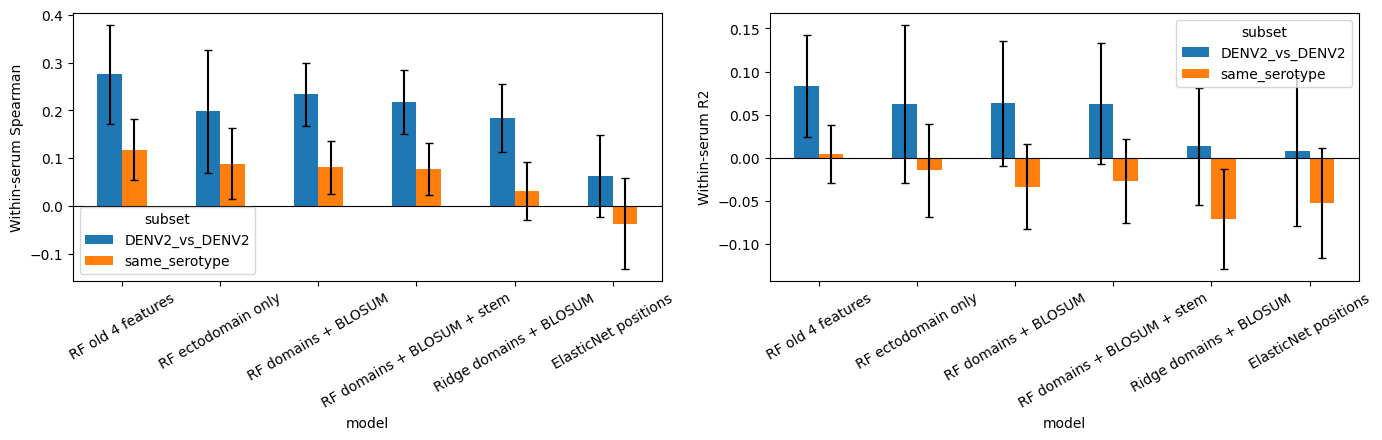

In [ ]:
order_models = list(configs4)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, metric, label in [(axes[0], "within_spearman", "Within-serum Spearman"),
                          (axes[1], "within_r2", "Within-serum R2")]:
    w = within4.groupby(["subset", "model"])[metric].agg(["mean", "std"])
    w["mean"].unstack()[order_models].T.plot(kind="bar", yerr=w["std"].unstack()[order_models].T,
                                              ax=ax, capsize=3, rot=30)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel(label)
plt.tight_layout()
plt.show()

# **Block 4.7: Which positions does elastic net pick**

In [ ]:
same_only = data[data["same_sero"]]
en = ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=5000)
en.fit(same_only[pos_cols].values, same_only["antigenic_distance"].values)
coef = pd.Series(en.coef_, index=range(1, ecto_n + 1))
top = coef[coef != 0].abs().sort_values(ascending=False).head(15)
print("Nonzero positions:", int((coef != 0).sum()))
print(coef[top.index].round(3).to_string())

Nonzero positions: 25
346    0.264
180   -0.260
204   -0.260
164    0.247
171    0.243
129    0.207
297    0.198
345   -0.192
202    0.188
83     0.168
380    0.158
52     0.154
351   -0.151
384   -0.133
124    0.131


# **Block 5.1: Parse the map**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from Bio import SeqIO
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

rows = []
with open("3d-antigenic-map.txt") as fh:
    for line in fh:
        parts = line.split()
        if len(parts) == 5 and parts[0] in ("AG", "SR"):
            rows.append([parts[0], parts[1], float(parts[2]), float(parts[3]), float(parts[4])])
map_df = pd.DataFrame(rows, columns=["type", "name", "x", "y", "z"])
print(map_df["type"].value_counts())

viruses = map_df[map_df["type"] == "AG"].reset_index(drop=True)
viruses["serotype"] = viruses["name"].str.split("/").str[0]
print(viruses["serotype"].value_counts())

type
AG    412
SR     36
Name: count, dtype: int64
serotype
DENV1    105
DENV4    105
DENV3    103
DENV2     99
Name: count, dtype: int64


# **Block 5.2: Match map viruses with E sequences**

In [ ]:
info = pd.read_csv("information.viruses.csv").drop_duplicates("unified.sequence.names")
e_seqs = {r.id: str(r.seq) for r in SeqIO.parse("E-sequences.fasta", "fasta")}

viruses["in_info"] = viruses["name"].isin(info["unified.sequence.names"])
viruses["in_fasta"] = viruses["name"].isin(e_seqs)
print(viruses[["in_info", "in_fasta"]].sum(), "of", len(viruses))
print("Not in fasta (first 10):", viruses.loc[~viruses["in_fasta"], "name"].head(10).tolist())

lengths = Counter(len(s) for s in e_seqs.values())
print("E length counts:", lengths.most_common(5))

in_info     412
in_fasta    412
dtype: int64 of 412
Not in fasta (first 10): []
E length counts: [(1485, 2030)]


# **Block 5.3: Metadata and vaccine-related strains**

In [ ]:
viruses = viruses.merge(info[["unified.sequence.names", "subset", "set", "year", "country", "genotype"]],
                        left_on="name", right_on="unified.sequence.names", how="left")
print(viruses["subset"].value_counts(dropna=False))
print(viruses.groupby("serotype")["genotype"].value_counts().head(25))

vaccine_pattern = "TONGA|NAURU|16681|PUO|SLEMAN|DOMINICA|VACCINE|PDK"
print(viruses.loc[viruses["name"].str.upper().str.contains(vaccine_pattern), ["name", "in_fasta"]])

subset
THAILAND         242
THAILAND.post    106
GLOBAL            40
CAMBODIA          18
THAILAND.pre       6
Name: count, dtype: int64
serotype  genotype            
DENV1     DENV1-I                 95
          DENV1-V                  8
          DENV1-II                 1
          DENV1-IV                 1
DENV2     DENV2-Asian I           83
          DENV2-Asian/American     7
          DENV2-Cosmopolitan       4
          DENV2-American           2
          DENV2-Sylvatic           2
          DENV2-Asian II           1
DENV3     DENV3-II                80
          DENV3-III               19
          DENV3-I                  3
          DENV3-IV                 1
DENV4     DENV4-I                 86
          DENV4-II                10
          DENV4-III                8
          DENV4-Sylvatic           1
Name: count, dtype: int64
                                      name  in_fasta
7            DENV1/NAURU/1974/RDENV1-WP-1A      True
200              DENV2/TONGA/1974

# **Block 5.4: Pairwise map distance (target)**

In [ ]:
use = viruses[viruses["in_fasta"]].reset_index(drop=True)
dist = squareform(pdist(use[["x", "y", "z"]].values))
i, j = np.triu_indices(len(use), k=1)

pairs = pd.DataFrame({"v1": use["name"].values[i], "v2": use["name"].values[j],
                      "sero1": use["serotype"].values[i], "sero2": use["serotype"].values[j],
                      "map_dist": dist[i, j]})
pairs["same_sero"] = pairs["sero1"] == pairs["sero2"]
print(len(use), "viruses ->", len(pairs), "pairs")
print(pairs.groupby("same_sero")["map_dist"].describe().round(2))

412 viruses -> 84666 pairs
             count  mean  std   min  25%   50%   75%    max
same_sero                                                  
False      63642.0  5.88  1.6  1.02  4.7  5.86  7.00  12.41
True       21024.0  2.01  1.1  0.05  1.2  1.84  2.61   7.78


# **Block 5.5: Map and distance plots**

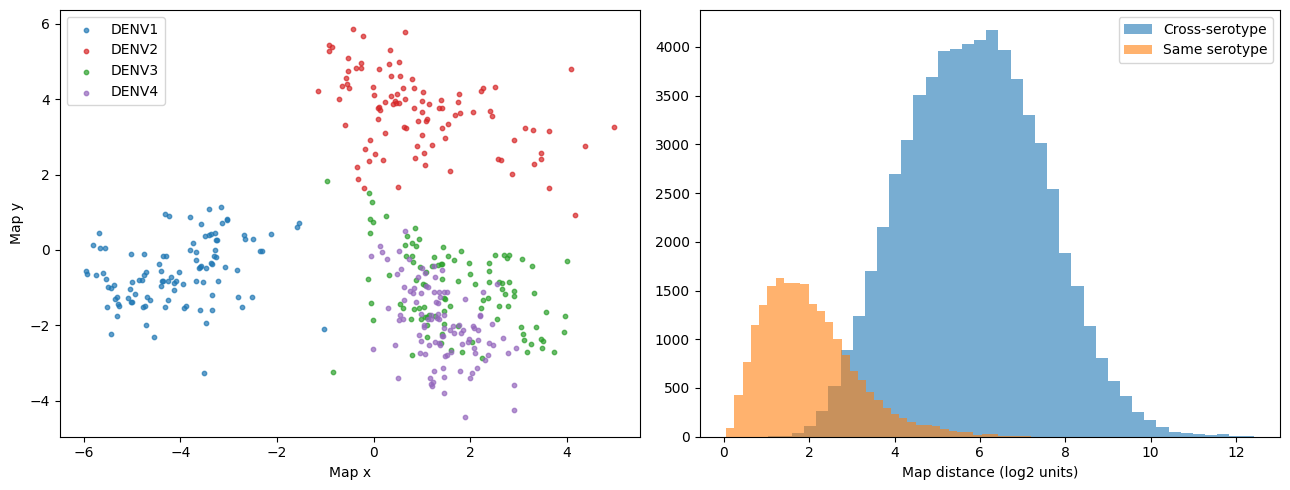

In [ ]:
colors = {"DENV1": "tab:blue", "DENV2": "tab:red", "DENV3": "tab:green", "DENV4": "tab:purple"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for s, c in colors.items():
    part = use[use["serotype"] == s]
    axes[0].scatter(part["x"], part["y"], s=10, color=c, alpha=0.7, label=s)
axes[0].set_xlabel("Map x")
axes[0].set_ylabel("Map y")
axes[0].legend()

axes[1].hist(pairs.loc[~pairs["same_sero"], "map_dist"], bins=40, alpha=0.6, label="Cross-serotype")
axes[1].hist(pairs.loc[pairs["same_sero"], "map_dist"], bins=40, alpha=0.6, label="Same serotype")
axes[1].set_xlabel("Map distance (log2 units)")
axes[1].legend()
plt.tight_layout()
plt.show()

# **Block 5.6: Does sequence difference predict map distance? (key test)**

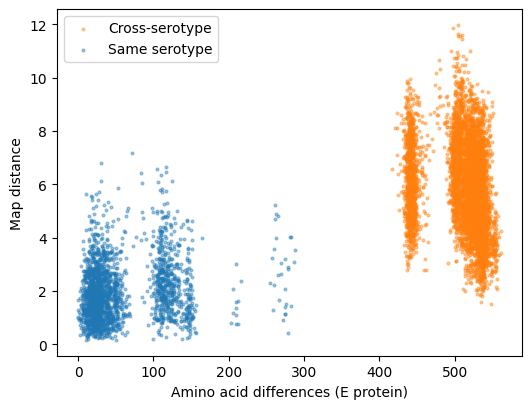

same_sero = False | Spearman(Hamming, map distance) = -0.327
same_sero = True | Spearman(Hamming, map distance) = 0.18


In [ ]:
if len(lengths) == 1:
    arr = {n: np.array(list(e_seqs[n])) for n in use["name"]}
    pairs["hamming"] = [(arr[a] != arr[b]).sum() for a, b in zip(pairs["v1"], pairs["v2"])]

    fig, ax = plt.subplots(figsize=(6, 4.5))
    for flag, color, label in [(False, "tab:orange", "Cross-serotype"), (True, "tab:blue", "Same serotype")]:
        part = pairs[pairs["same_sero"] == flag].sample(frac=0.1, random_state=0)
        ax.scatter(part["hamming"], part["map_dist"], s=4, alpha=0.4, color=color, label=label)
    ax.set_xlabel("Amino acid differences (E protein)")
    ax.set_ylabel("Map distance")
    ax.legend()
    plt.show()

    for flag in [False, True]:
        part = pairs[pairs["same_sero"] == flag]
        rho = spearmanr(part["hamming"], part["map_dist"])[0]
        print("same_sero =", flag, "| Spearman(Hamming, map distance) =", round(rho, 3))
else:
    print("E sequences have different lengths: alignment is needed first")